# AI-Based E-Commerce Product Price Prediction

## Project Objective

The objective of this project is to develop a Machine Learning model
that predicts product prices using e-commerce transaction data.

The project includes data preprocessing, exploratory data analysis,
feature engineering, categorical encoding, machine learning model
training, prediction and model evaluation.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_excel("6-8Lakh-Online-shoppers.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (684245, 9)


,S.no,Customer_Name,Customer_Mobile,Customer_Email_id,State,Item_Name,Item_Price,Payment_Option,Payment_Through
0,1,ANUJ SINGH,9999074691,anujssingh@gmail.com,Haryana,Pinwheel Viscose Crop Tops - Blue,459,Net Banking,State Bank Of India
1,2,RAJESH SINHA,9971304149,rajesh_patna@yahoo.com,Uttar Pradesh,YUGVAASTRA Satin Nighty & Night Gowns - Black,626,Credit Card,State Bank Of India
2,3,ANANTH TANTRY,9833361151,ananth_tantry@yahoo.com,Maharashtra,Charcoal Face Mask Anti Blackhead For Men & Wo...,160,Net Banking,Bank Of Baroda
3,4,shibu chacko,9880193257,koruthusc@gmail.com,Karnataka,Bhagya Lakshmi Traditional Gold Plated Bangles...,267,Credit Card,ICICI Bank
4,5,swapnil dongre,9919501244,dongre_swapnil@yahoo.co.in,Uttar Pradesh,Probeatz 20 20000 -mAh Li-Ion Solar Power Bank...,1049,Credit Card,ICICI Bank


In [4]:
print("Dataset Information:")
print("--------------------")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

Dataset Information:
--------------------
Rows: 684245
Columns: 9

Column Names:
['S.no', 'Customer_Name', 'Customer_Mobile', 'Customer_Email_id', 'State', 'Item_Name', 'Item_Price', 'Payment_Option', 'Payment_Through']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 684245 entries, 0 to 684244
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   S.no               684245 non-null  int64
 1   Customer_Name      684245 non-null  str  
 2   Customer_Mobile    684245 non-null  int64
 3   Customer_Email_id  684245 non-null  str  
 4   State              684245 non-null  str  
 5   Item_Name          684245 non-null  str  
 6   Item_Price         684245 non-null  int64
 7   Payment_Option     684245 non-null  str  
 8   Payment_Through    585238 non-null  str  
dtypes: int64(3), str(6)
memory usage: 115.6 MB


In [5]:
# Remove personal information columns
df = df.drop(columns=[
    "Customer_Name",
    "Customer_Mobile",
    "Customer_Email_id"
], errors="ignore")

# Remove unnecessary serial number column
df = df.drop(columns=["S.no"], errors="ignore")

# Check remaining columns
print("Remaining Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Remaining Columns:
['State', 'Item_Name', 'Item_Price', 'Payment_Option', 'Payment_Through']

Missing Values:
State                  0
Item_Name              0
Item_Price             0
Payment_Option         0
Payment_Through    99007
dtype: int64


In [6]:
print("Basic Statistical Summary:")
df.describe(include="all")

Basic Statistical Summary:


,State,Item_Name,Item_Price,Payment_Option,Payment_Through
count,684245,684245,684245.000000,684245,585238
unique,134,1271,NaN,6,9
top,Tamil Nadu,Boosah Satin Nighty & Night Gowns,NaN,Credit Card,Axis Bank
freq,96709,4000,NaN,246010,179796
mean,NaN,NaN,1605.600132,NaN,NaN
std,NaN,NaN,4489.680985,NaN,NaN
min,NaN,NaN,65.000000,NaN,NaN
25%,NaN,NaN,441.000000,NaN,NaN
50%,NaN,NaN,611.000000,NaN,NaN
75%,NaN,NaN,907.000000,NaN,NaN


Top 10 States by Orders:
State
Tamil Nadu        96709
Maharashtra       93112
Andhra Pradesh    77503
Uttar Pradesh     70870
Delhi             61745
Karnataka         60317
Madhya Pradesh    29214
Gujarat           27100
West Bengal       26730
Kerala            25262
Name: count, dtype: int64


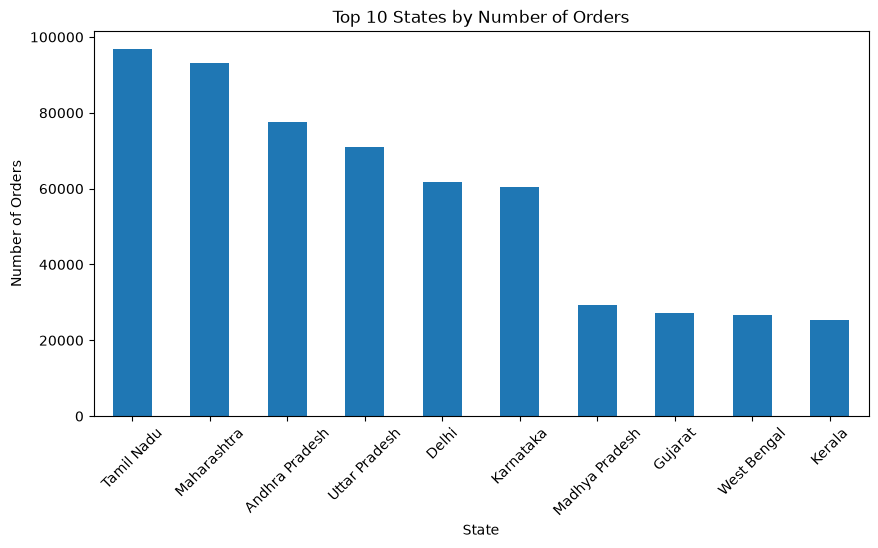

In [7]:
state_orders = df["State"].value_counts().head(10)

print("Top 10 States by Orders:")
print(state_orders)

plt.figure(figsize=(10, 5))
state_orders.plot(kind="bar")
plt.title("Top 10 States by Number of Orders")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Top 10 Products by Orders:
Item_Name
Boosah Satin Nighty & Night Gowns                          4000
D Naked Net Baby Doll Dresses With Panty                   3414
Broadstar Denim Lycra Jeans                                2918
Freesia Nylon Tube Bra                                     2066
D Naked Net Baby Doll Dresses With Panty - Black           2030
Modish Vogue Poly Satin Baby Doll Dresses Without Panty    1512
Khushfashions Satin Nighty & Night Gowns                   1497
Bailey Satin Nighty & Night Gowns                          1482
Broadstar Denim Jeans - Blue                               1473
Wetex Premium Nylon Tube Tops                              1452
Name: count, dtype: int64


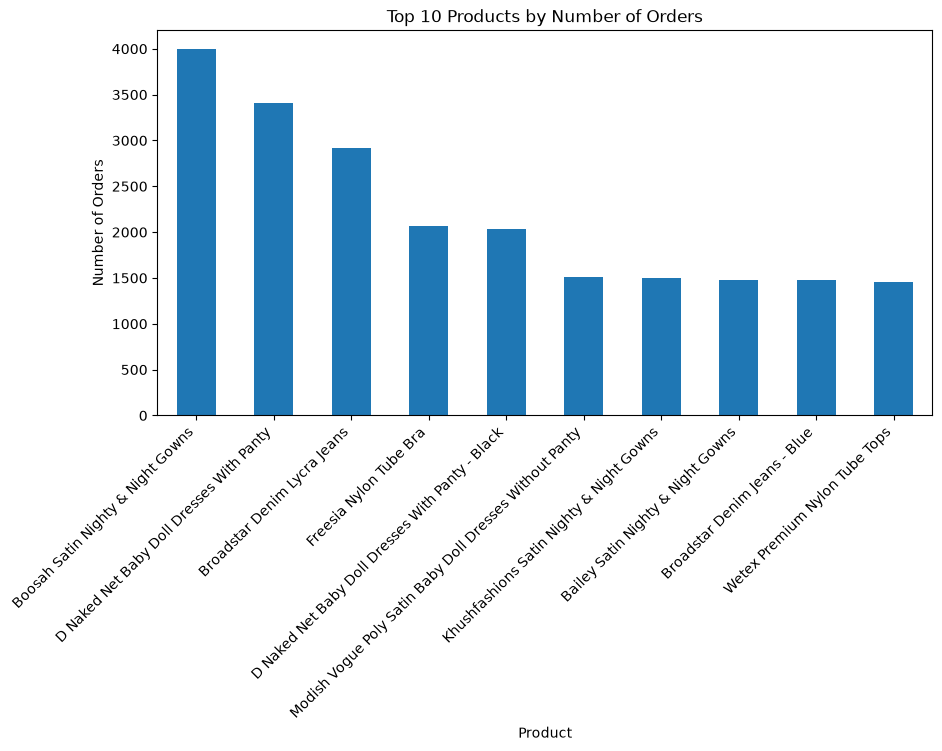

In [8]:
product_orders = df["Item_Name"].value_counts().head(10)

print("Top 10 Products by Orders:")
print(product_orders)

plt.figure(figsize=(10, 5))
product_orders.plot(kind="bar")
plt.title("Top 10 Products by Number of Orders")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.show()

Payment Options:
Payment_Option
Credit Card         246010
Net Banking         219377
Cash On Delivery     99007
Debit Card           55008
Net banking          37414
Credit card          27429
Name: count, dtype: int64


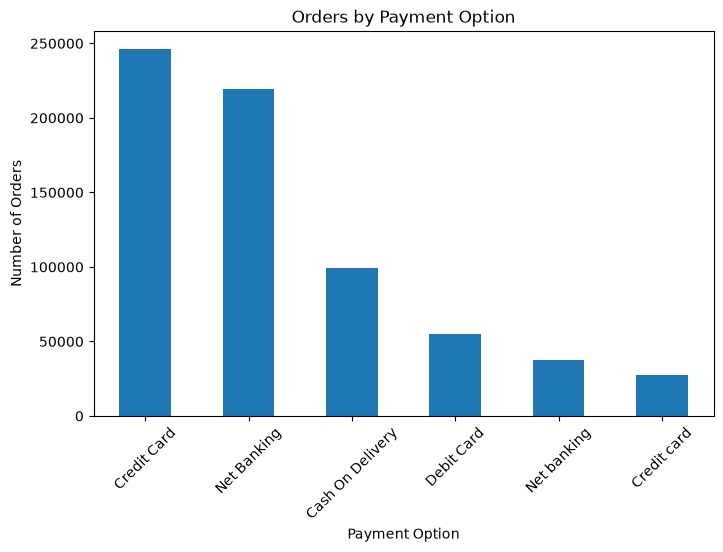

In [9]:
payment_counts = df["Payment_Option"].value_counts()

print("Payment Options:")
print(payment_counts)

plt.figure(figsize=(8, 5))
payment_counts.plot(kind="bar")
plt.title("Orders by Payment Option")
plt.xlabel("Payment Option")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

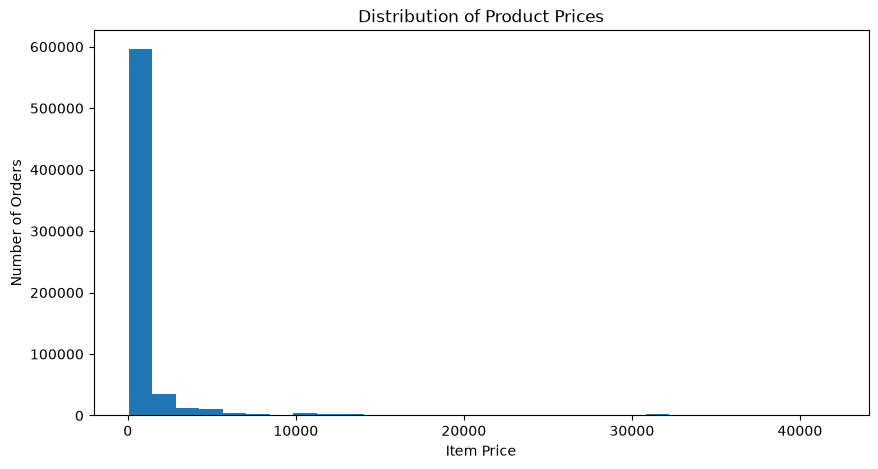

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df["Item_Price"], bins=30)
plt.title("Distribution of Product Prices")
plt.xlabel("Item Price")
plt.ylabel("Number of Orders")
plt.show()

Average Product Price by Payment Option:
Payment_Option
Cash On Delivery    1617.688921
Net Banking         1616.511977
Credit Card         1603.945632
Net banking         1599.416021
Debit Card          1576.215096
Credit card         1556.897116
Name: Item_Price, dtype: float64


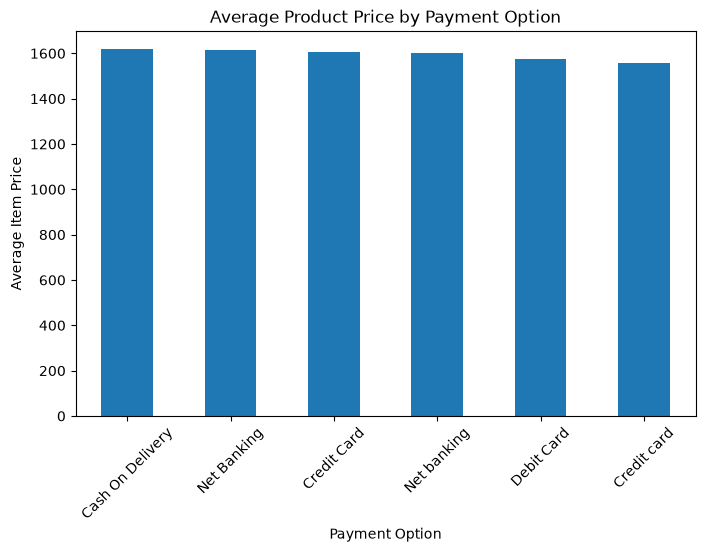

In [11]:
avg_price_payment = df.groupby("Payment_Option")["Item_Price"].mean().sort_values(ascending=False)

print("Average Product Price by Payment Option:")
print(avg_price_payment)

plt.figure(figsize=(8, 5))
avg_price_payment.plot(kind="bar")
plt.title("Average Product Price by Payment Option")
plt.xlabel("Payment Option")
plt.ylabel("Average Item Price")
plt.xticks(rotation=45)
plt.show()

In [12]:
# Target variable
y = df["Item_Price"]

# Input features
X = df[[
    "State",
    "Item_Name",
    "Payment_Option",
    "Payment_Through"
]]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Item_Price")

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Input Features:
['State', 'Item_Name', 'Payment_Option', 'Payment_Through']

Target:
Item_Price

X Shape: (684245, 4)
y Shape: (684245,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (547396, 4)
Testing data: (136849, 4)


In [14]:
# Categorical columns
categorical_features = [
    "State",
    "Item_Name",
    "Payment_Option",
    "Payment_Through"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# AI/ML Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Complete pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("AI model pipeline created successfully!")

AI model pipeline created successfully!


In [15]:
# Use a smaller sample for faster AI model training
sample_size = min(100000, len(X_train))

X_train_sample = X_train.sample(
    n=sample_size,
    random_state=42
)

y_train_sample = y_train.loc[X_train_sample.index]

# Faster Random Forest
fast_model = RandomForestRegressor(
    n_estimators=20,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Create pipeline
fast_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", fast_model)
    ]
)

print("Training started...")

fast_pipeline.fit(X_train_sample, y_train_sample)

print("AI model trained successfully!")

Training started...
AI model trained successfully!


In [16]:
# Make predictions on test data
y_pred = fast_pipeline.predict(X_test)

print("Prediction completed successfully!")
print("First 10 Predicted Prices:")
print(y_pred[:10])

Prediction completed successfully!
First 10 Predicted Prices:
[1212.24915714 1212.24915714 1212.24915714 1212.24915714 1212.24915714
 1212.24915714 1212.24915714 1212.24915714 1212.24915714 1212.24915714]


In [17]:
# Make predictions on test data
y_pred = fast_pipeline.predict(X_test)

print("Prediction completed successfully!")
print("First 10 Predicted Prices:")
print(y_pred[:10])

Prediction completed successfully!
First 10 Predicted Prices:
[1212.24915714 1212.24915714 1212.24915714 1212.24915714 1212.24915714
 1212.24915714 1212.24915714 1212.24915714 1212.24915714 1212.24915714]


In [18]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("========== MODEL EVALUATION ==========")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

========== MODEL EVALUATION ==========
Mean Absolute Error (MAE): 1086.4
Root Mean Squared Error (RMSE): 2673.92
R² Score: 0.6453


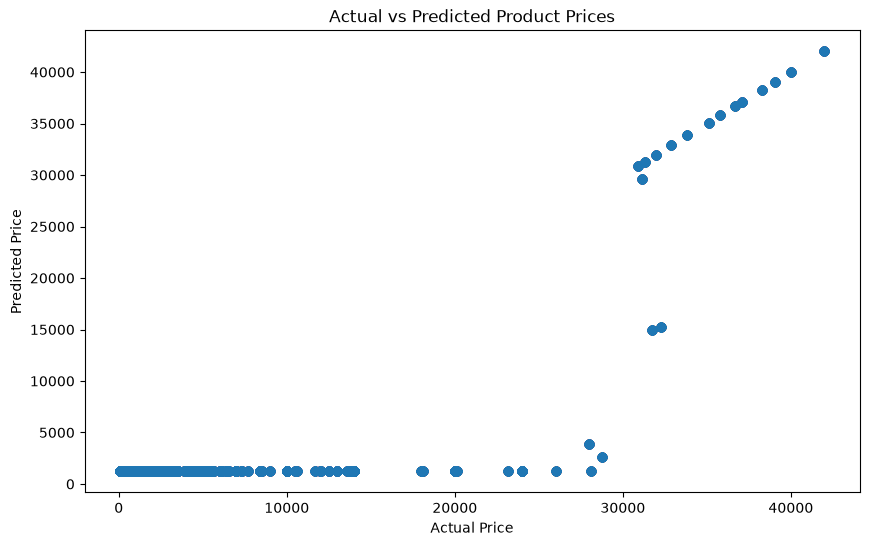

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Product Prices")

plt.show()

In [20]:
# Show actual vs predicted prices

results = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
})

results["Predicted Price"] = results["Predicted Price"].round(2)

results

,Actual Price,Predicted Price
0,488,1212.25
1,420,1212.25
2,595,1212.25
3,389,1212.25
4,409,1212.25
5,1011,1212.25
6,474,1212.25
7,509,1212.25
8,4290,1212.25
9,20156,1212.25


## Key Business Insights

- Machine Learning was used to predict e-commerce product prices.
- Product name, state and payment-related features were used as input variables.
- The Random Forest Regression model was trained on historical e-commerce data.
- Model performance was evaluated using MAE, RMSE and R² Score.
- The Actual vs Predicted graph helps compare model predictions with actual prices.

## Business Recommendations

1. Use AI-based price prediction to support pricing decisions.
2. Analyze product and state-level patterns before setting prices.
3. Use historical transaction data to improve future predictions.
4. Monitor model performance regularly and retrain the model with new data.

# Final Conclusion

This project demonstrates the use of Artificial Intelligence and
Machine Learning for e-commerce product price prediction.

The dataset was cleaned and analyzed before training the model.
A Random Forest Regression model was used to predict product prices
based on available e-commerce features.

The model was evaluated using MAE, RMSE and R² Score.

This project shows how Machine Learning can be applied to historical
e-commerce data to support data-driven pricing decisions.